# PCA MMSS Dislocation — QDB Grid Search

Full QueryDrivenBacktest per config. Adds momentum confirmation + CFTC positioning filter per §7.3.

**Three-frame conviction:** Only enter when dislocation + momentum + positioning agree:
- **Dislocation:** PCA residual z-score exceeds threshold
- **Momentum:** trailing return sign confirms reversion has started
- **Positioning:** CFTC leveraged-money net is under/over-owned (crowded → reversal risk)

In [1]:
%load_ext autoreload
%autoreload 2

import datetime, sys, os, time, itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import QuantLib as ql

plt.style.use('ggplot')
pylab.rcParams.update({
    'legend.fontsize': 'x-large', 'figure.figsize': (18, 8),
    'axes.labelsize': 'x-large', 'axes.titlesize': 'x-large',
    'xtick.labelsize': 'large', 'ytick.labelsize': 'large',
})

sys.path.append('../../')

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements
from BT.query_tearsheet import QueryBacktestTearSheet

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue
from Query.FixedRateBonds.carry_roll import load_us_treasury_gc_fixing_pct
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

from BT.signals.tfp_swap_spread import CT_MAP, build_tfp_history
from BT.signals.irswap_pca_rv_scanner import IRSwapPCARVConfig, _rolling_pca_surface
from BT.signals.cftc_positioning import build_positioning_panel, positioning_zscore
from RVUtils.plt_timeseries import make_secondary_axis_plot

## Load Data

In [2]:
BT_START = datetime.date(2021, 6, 1)
BT_END   = datetime.date(2026, 5, 14)
TENORS   = ['2Y', '3Y', '5Y', '7Y', '10Y', '30Y']
RISK_BPV = 100_000

# ── MMSS panel ──
CACHE = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'BT', 'results', 'tfp_screener', 'tfp_history.parquet'))
history = pd.read_parquet(CACHE)
history.index = pd.to_datetime(history.index)
mmss_panel = pd.DataFrame({t: history[f'mmss_{t}'] for t in TENORS if f'mmss_{t}' in history.columns}).dropna()
print(f'MMSS panel: {mmss_panel.shape}')

# ── PCA ──
pca_cfg = IRSwapPCARVConfig(pca_window_days=520, pca_input='changes', n_components=3, zscore_lookback_days=260)
residuals, zscores, var_exp, _, _ = _rolling_pca_surface(mmss_panel, pca_cfg)
print(f'PCA done. Var explained: {var_exp.dropna().tail(60).sum(axis=1).mean():.1%}')

# ── CFTC positioning ──
CFTC_CACHE = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'BT', 'results', 'tfp_screener', 'cftc_raw.parquet'))
pos_panel = build_positioning_panel(cache_path=CFTC_CACHE, tenors=['2Y', '5Y', '10Y', '30Y'], metric='lev_net')
pos_z = positioning_zscore(pos_panel, window=52)
# Forward-fill to all tenors (3Y, 7Y use nearest)
pos_z['3Y'] = pos_z.get('2Y', pd.Series(dtype=float))
pos_z['7Y'] = pos_z.get('5Y', pd.Series(dtype=float))
pos_z = pos_z.reindex(mmss_panel.index, method='ffill')
print(f'CFTC positioning: {pos_panel.shape}')

# ── Momentum (trailing 21d return) ──
momentum = mmss_panel.diff(21)  # 21d change in MMSS
print(f'Momentum computed (21d lookback)')

MMSS panel: (1475, 6)
PCA done. Var explained: 95.4%
CFTC positioning: (1656, 4)
Momentum computed (21d lookback)


## Signal Generator with Momentum + Positioning Filters

In [3]:
def generate_filtered_signals(
    zscores, momentum, pos_z, tenor,
    z_entry=1.5, z_exit=0.0, max_hold=60,
    use_momentum=True, mom_window=21,
    use_positioning=True, pos_threshold=0.5,
):
    """Three-frame signal: dislocation + momentum + positioning.
    
    Entry requires ALL active filters to agree:
      - Dislocation: |z| > z_entry
      - Momentum: trailing MMSS change confirms reversion direction
        (z < 0 → cheap → want MMSS rising → mom > 0 = reversion started)
      - Positioning: lev money z-score indicates under/over-owned
        (z < 0 → cheap → want positioning z < -pos_threshold = under-owned)
    """
    z = zscores[tenor].values if tenor in zscores.columns else np.full(len(zscores), np.nan)
    mom = momentum[tenor].values if tenor in momentum.columns else np.zeros(len(zscores))
    pz = pos_z[tenor].values if tenor in pos_z.columns else np.zeros(len(zscores))
    
    n = len(z)
    sig = np.zeros(n, dtype=np.int8)
    pos = 0; hold = 0
    
    for i in range(n):
        v = z[i]
        if np.isnan(v):
            sig[i] = 0; pos = 0; hold = 0; continue
        
        if pos == 0:
            # Entry: dislocation says cheap (z < -z_entry)
            if v < -z_entry:
                # Momentum: MMSS rising (reversion started)
                mom_ok = (not use_momentum) or (not np.isnan(mom[i]) and mom[i] > 0)
                # Positioning: under-owned (lev money z-score negative)
                pos_ok = (not use_positioning) or (np.isnan(pz[i])) or (pz[i] < -pos_threshold)
                if mom_ok and pos_ok:
                    pos = +1; hold = 0
            
            # Entry: dislocation says rich (z > z_entry)
            elif v > z_entry:
                mom_ok = (not use_momentum) or (not np.isnan(mom[i]) and mom[i] < 0)
                pos_ok = (not use_positioning) or (np.isnan(pz[i])) or (pz[i] > pos_threshold)
                if mom_ok and pos_ok:
                    pos = -1; hold = 0
        else:
            hold += 1
            exit_now = hold >= max_hold
            if not exit_now:
                if pos == +1 and v >= -z_exit: exit_now = True
                elif pos == -1 and v <= z_exit: exit_now = True
            if exit_now: pos = 0; hold = 0
        
        sig[i] = pos
    
    return pd.Series(sig, index=zscores.index)


def extract_events(sig_series, tenor, bt_start, bt_end):
    sig = sig_series.loc[bt_start:bt_end]
    dates = [d.date() if hasattr(d, 'date') else d for d in sig.index]
    vals = sig.values; events = []; prev = 0; entry_date = None; direction = 0
    for i in range(len(vals)):
        cur = int(vals[i])
        if prev == 0 and cur != 0:
            entry_date = dates[i]; direction = cur
        elif prev != 0 and cur == 0:
            events.append(dict(entry_date=entry_date, exit_date=dates[i], direction=direction, tenor=tenor, tag=f'pca-{tenor}-{entry_date}'))
            entry_date = None; direction = 0
        elif prev != 0 and cur != 0 and cur != prev:
            events.append(dict(entry_date=entry_date, exit_date=dates[i], direction=direction, tenor=tenor, tag=f'pca-{tenor}-{entry_date}'))
            entry_date = dates[i]; direction = cur
        prev = cur
    if entry_date is not None:
        events.append(dict(entry_date=entry_date, exit_date=dates[-1], direction=direction, tenor=tenor, tag=f'pca-{tenor}-{entry_date}'))
    return events

## QDB Infrastructure (shared across configs)

In [4]:
CAL = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
tg = TimeGrid(ql_cal_date_range(ql_cal=CAL, start=BT_START, end=BT_END))

gc_fixing_pct = pd.Series(
    {d: load_us_treasury_gc_fixing_pct(d) for d in sorted({ts.date() for ts in tg})},
    dtype=float,
).sort_index().ffill().bfill()

financing_config = {
    'mode': 'gc_plus_specialness',
    'gc_rate': gc_fixing_pct / 100.0,
    'leg_specialness_bps': {'outright': 10.0},
    'day_count': 'ACT/360',
    'haircut': 0.0,
}

frb_mdp = FixedRateBondsMDP(source='USTS_FEDINVEST_WSJ_LIVE-QL')
irs_mdp = IRSwapsMDP(source='ERIS_EOD_LIVE-RL_BASIC')

print(f'TimeGrid: {sum(1 for _ in TimeGrid(ql_cal_date_range(ql_cal=CAL, start=BT_START, end=BT_END)))} steps')
print(f'GC range: {gc_fixing_pct.min():.2f}% to {gc_fixing_pct.max():.2f}%')

TimeGrid: 1239 steps
GC range: 0.01% to 5.40%


## Run QDB for a Single Config

In [5]:
def run_qdb_config(trade_tenors, z_entry, z_exit, max_hold,
                    use_momentum=True, mom_window=21,
                    use_positioning=True, pos_threshold=0.5,
                    unwind_fee_bps=0.5, label=''):
    """Run one config through full QueryDrivenBacktest. Returns metrics dict."""
    # Generate signals
    all_events = []
    for tenor in trade_tenors:
        sig = generate_filtered_signals(
            zscores, momentum, pos_z, tenor,
            z_entry=z_entry, z_exit=z_exit, max_hold=max_hold,
            use_momentum=use_momentum, mom_window=mom_window,
            use_positioning=use_positioning, pos_threshold=pos_threshold,
        )
        evts = extract_events(sig, tenor, BT_START, BT_END)
        all_events.extend(evts)
    
    if not all_events:
        return None
    
    # Build triggers
    triggers = []
    for ev in all_events:
        tag, ct = ev['tag'], CT_MAP[ev['tenor']]
        d = ev['direction']
        bond_q = FixedRateBondQuery(
            cusip=ct, value=FixedRateBondValue.NPV,
            structure_kwargs={'bpv': RISK_BPV * d},
            meta={'financing': financing_config}, tags=(tag,),
        )
        swap_q = IRSwapQuery(
            curve='USD-SOFR-1D', tenor=ev['tenor'], value=IRSwapValue.NPV,
            structure_kwargs={'bpv': -RISK_BPV * d}, tags=(tag,),
        )
        triggers.append(DateTrigger(
            DateTriggerRequirements(dates=[ev['entry_date']]),
            actions=[AddQueryAction(query=bond_q), AddQueryAction(query=swap_q)],
        ))
        triggers.append(DateTrigger(
            DateTriggerRequirements(dates=[ev['exit_date']]),
            actions=[UnwindPositionsAction(match_tag=tag, fee=unwind_fee_bps * RISK_BPV)],
        ))
    
    # Run backtest
    strategy = QueryStrategy(
        name=label or f'PCA {z_entry}/{z_exit} mom={use_momentum} pos={use_positioning}',
        triggers=triggers,
        mdps={'FRB': frb_mdp, 'IRS': irs_mdp},
    )
    bt = QueryDrivenBacktest(time_grid=tg, strategy=strategy)
    t0 = time.time()
    bt.run()
    elapsed = time.time() - t0
    
    # Extract metrics
    mtm = pd.Series(bt.mtm_history).sort_index()
    daily = mtm.diff().dropna()
    sharpe = daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else 0
    max_dd = (mtm - mtm.cummax()).min()
    
    # Trade stats from closed positions
    n_trades = len(all_events)
    n_winners = 0
    avg_hold = 0
    closed = pd.DataFrame(bt.portfolio.closed_positions_log)
    if not closed.empty:
        def _tag(row):
            sq = row.get('source_query', None)
            if sq and hasattr(sq, 'tags') and sq.tags: return sq.tags[0]
            pos = row.get('position', None)
            if pos and hasattr(pos, 'source_query') and hasattr(pos.source_query, 'tags') and pos.source_query.tags: return pos.source_query.tags[0]
            return None
        closed['tag'] = closed.apply(_tag, axis=1)
        cw = closed.dropna(subset=['tag'])
        if not cw.empty:
            tp = cw.groupby('tag').agg(pnl=('realized_pnl', 'sum'), days=('holding_period_days', 'mean'))
            n_trades = len(tp)
            n_winners = (tp['pnl'] > 0).sum()
            avg_hold = tp['days'].mean()
    
    return dict(
        tenors='+'.join(trade_tenors), z_entry=z_entry, z_exit=z_exit,
        max_hold=max_hold, momentum=use_momentum, positioning=use_positioning,
        pos_thresh=pos_threshold,
        sharpe=round(sharpe, 3), final_mtm=round(mtm.iloc[-1]),
        max_dd=round(max_dd), trades=n_trades,
        hit=round(n_winners / n_trades, 3) if n_trades > 0 else 0,
        avg_hold=round(avg_hold, 1), elapsed=round(elapsed, 0),
        bt=bt, mtm=mtm,
    )

## Grid Search

Focused grid — vary signal filters while keeping PCA fixed. Each config runs full QDB.

In [6]:
configs = [
    # Baseline: dislocation only (no filters)
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=1.5, z_exit=0.0, max_hold=60,
         use_momentum=False, use_positioning=False, label='baseline z=1.5/0.0'),
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=1.5, z_exit=-0.5, max_hold=60,
         use_momentum=False, use_positioning=False, label='baseline z=1.5/-0.5'),
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=2.0, z_exit=0.0, max_hold=60,
         use_momentum=False, use_positioning=False, label='baseline z=2.0/0.0'),
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=2.0, z_exit=-0.5, max_hold=90,
         use_momentum=False, use_positioning=False, label='baseline z=2.0/-0.5 h90'),
    
    # Momentum only
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=1.5, z_exit=0.0, max_hold=60,
         use_momentum=True, use_positioning=False, label='+momentum z=1.5/0.0'),
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=2.0, z_exit=0.0, max_hold=60,
         use_momentum=True, use_positioning=False, label='+momentum z=2.0/0.0'),
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=1.5, z_exit=-0.5, max_hold=90,
         use_momentum=True, use_positioning=False, label='+momentum z=1.5/-0.5 h90'),
    
    # Positioning only
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=1.5, z_exit=0.0, max_hold=60,
         use_momentum=False, use_positioning=True, pos_threshold=0.5, label='+positioning z=1.5/0.0'),
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=2.0, z_exit=0.0, max_hold=60,
         use_momentum=False, use_positioning=True, pos_threshold=0.5, label='+positioning z=2.0/0.0'),
    
    # Both: three-frame conviction
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=1.5, z_exit=0.0, max_hold=60,
         use_momentum=True, use_positioning=True, pos_threshold=0.5, label='3-frame z=1.5/0.0'),
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=1.5, z_exit=-0.5, max_hold=90,
         use_momentum=True, use_positioning=True, pos_threshold=0.5, label='3-frame z=1.5/-0.5 h90'),
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=2.0, z_exit=0.0, max_hold=60,
         use_momentum=True, use_positioning=True, pos_threshold=0.5, label='3-frame z=2.0/0.0'),
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=2.0, z_exit=-0.5, max_hold=90,
         use_momentum=True, use_positioning=True, pos_threshold=0.5, label='3-frame z=2.0/-0.5 h90'),
    dict(trade_tenors=['2Y','7Y','10Y'], z_entry=2.0, z_exit=-0.5, max_hold=90,
         use_momentum=True, use_positioning=True, pos_threshold=1.0, label='3-frame z=2.0/-0.5 h90 p1.0'),
]

print(f'Running {len(configs)} configs through full QDB...')
results = []
for i, cfg in enumerate(configs):
    label = cfg.pop('label', f'config_{i}')
    print(f'\n[{i+1}/{len(configs)}] {label}', flush=True)
    r = run_qdb_config(**cfg, label=label)
    if r is not None:
        r['label'] = label
        results.append(r)
        print(f'  Sharpe={r["sharpe"]}  MTM={r["final_mtm"]:,}  trades={r["trades"]}  hold={r["avg_hold"]}d  time={r["elapsed"]}s', flush=True)
    else:
        print(f'  No trades', flush=True)

Running 14 configs through full QDB...

[1/14] baseline z=1.5/0.0


BACKTESTING...:  39%|███▉      | 487/1239 [00:00<00:00, 4863.73step/s]

The supplied `fixings` contain more fixings than were expected by the holiday calendar of the `curve`.
The additional fixing dates are shown in the underlying KeyError message below.
If the Series you are providing contains valid fixings the fault probably lies with Rateslib calendar definitions and should be reported.
This error can avoided by excluding these fixings using Series.pop().
"[Timestamp('2025-04-18 00:00:00')] not in index"


BACKTESTING...: 100%|██████████| 1239/1239 [00:30<00:00, 40.73step/s] 

  Sharpe=-0.115  MTM=-3,653,660  trades=140  hold=2.1d  time=30.0s

[2/14] baseline z=1.5/-0.5


...

  Sharpe=-0.366  MTM=-540,712  trades=4  hold=2.8d  time=2.0s

[13/14] 3-frame z=2.0/-0.5 h90



BACKTESTING...: 100%|██████████| 1239/1239 [00:02<00:00, 590.34step/s]

  Sharpe=-0.539  MTM=-841,235  trades=4  hold=5.0d  time=2.0s

[14/14] 3-frame z=2.0/-0.5 h90 p1.0



BACKTESTING...: 100%|██████████| 1239/1239 [00:00<00:00, 5599.20step/s]

  Sharpe=-0.451  MTM=-166,314  trades=1  hold=3.0d  time=0.0s


## Results Comparison

In [7]:
summary = pd.DataFrame([{k: v for k, v in r.items() if k not in ('bt', 'mtm')} for r in results])
summary = summary.sort_values('sharpe', ascending=False)
summary

,tenors,z_entry,z_exit,max_hold,momentum,positioning,pos_thresh,sharpe,final_mtm,max_dd,trades,hit,avg_hold,elapsed,label
4,2Y+7Y+10Y,1.5,0.0,60,True,False,0.5,0.224,4921230,-8818797,72,0.458,2.1,15.0,+momentum z=1.5/0.0
9,2Y+7Y+10Y,1.5,0.0,60,True,True,0.5,0.119,1485725,-6049435,26,0.462,2.2,6.0,3-frame z=1.5/0.0
10,2Y+7Y+10Y,1.5,-0.5,90,True,True,0.5,0.117,1479312,-6469295,26,0.538,3.7,10.0,3-frame z=1.5/-0.5 h90
1,2Y+7Y+10Y,1.5,-0.5,60,False,False,0.5,0.033,1217063,-20548758,132,0.576,3.2,41.0,baseline z=1.5/-0.5
5,2Y+7Y+10Y,2.0,0.0,60,True,False,0.5,-0.009,-106892,-3800115,23,0.348,2.1,6.0,+momentum z=2.0/0.0
6,2Y+7Y+10Y,1.5,-0.5,90,True,False,0.5,-0.089,-2667862,-16134701,71,0.493,3.5,25.0,+momentum z=1.5/-0.5 h90
0,2Y+7Y+10Y,1.5,0.0,60,False,False,0.5,-0.115,-3653660,-16749462,140,0.514,2.1,30.0,baseline z=1.5/0.0
7,2Y+7Y+10Y,1.5,0.0,60,False,True,0.5,-0.358,-7296491,-15028472,69,0.551,2.0,15.0,+positioning z=1.5/0.0
11,2Y+7Y+10Y,2.0,0.0,60,True,True,0.5,-0.366,-540712,-951074,4,0.250,2.8,2.0,3-frame z=2.0/0.0
8,2Y+7Y+10Y,2.0,0.0,60,False,True,0.5,-0.408,-3250280,-4844623,23,0.478,1.8,5.0,+positioning z=2.0/0.0


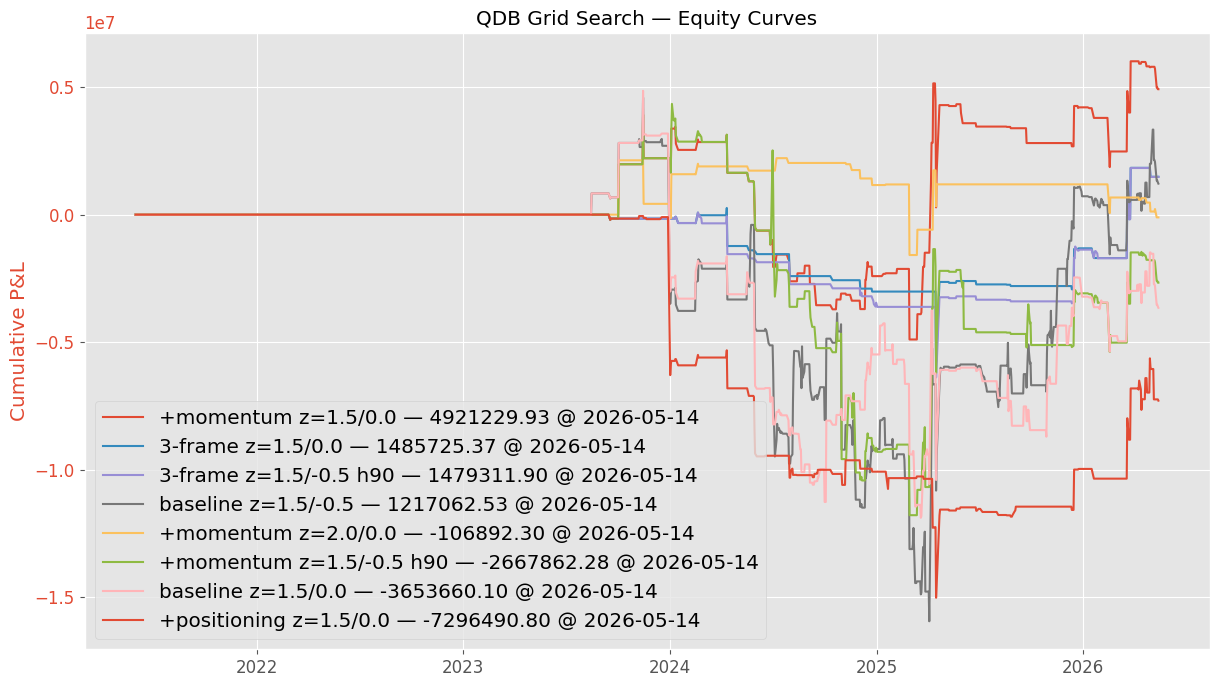

In [10]:
# Equity curve comparison
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Cumulative P&L', title='QDB Grid Search — Equity Curves',
)
for r in sorted(results, key=lambda x: -x['sharpe'])[:8]:
    # plot(r['mtm'].rename(r['label']), which='left', indicators=[{'kind': 'last', 'hide': True}])
    plot(r['mtm'].rename(r['label']), which='left')
legend(show_date=True)
plt.show()

## Best Config — Tearsheet

In [9]:
best = max(results, key=lambda r: r['sharpe'])
print(f'Best config: {best["label"]}')
print(f'Sharpe={best["sharpe"]}  MTM={best["final_mtm"]:,}  MaxDD={best["max_dd"]:,}  Trades={best["trades"]}  Hit={best["hit"]:.0%}  Hold={best["avg_hold"]}d')

try:
    tearsheet = QueryBacktestTearSheet.from_backtest(best['bt'])
    plotly_fig = tearsheet.plot_plotly()
    plotly_fig.show()
except Exception as e:
    print(f'Tearsheet: {e}')

Best config: +momentum z=1.5/0.0
Sharpe=0.224  MTM=4,921,230  MaxDD=-8,818,797  Trades=72  Hit=46%  Hold=2.1d
